In [1]:
!pip install opencv-python matplotlib scikit-learn

In [3]:
from google.colab import files
uploaded = files.upload()

Saving agriculture-plantation-soybean-field-green-600nw-2193842589.webp to agriculture-plantation-soybean-field-green-600nw-2193842589 (1).webp
Saving carrot-crop-leaves-shining-sunlight-close-up-view-close-up-view-carrot-daucus-carota-crop-leaves-illuminated-sunlight-442967442.webp to carrot-crop-leaves-shining-sunlight-close-up-view-close-up-view-carrot-daucus-carota-crop-leaves-illuminated-sunlight-442967442 (1).webp
Saving colocasia-esculenta-taro-crop-plant-large-lush-green-leaves-tropical-garden-plant-grown-colocasia-esculenta-taro-crop-plant-413730488.webp to colocasia-esculenta-taro-crop-plant-large-lush-green-leaves-tropical-garden-plant-grown-colocasia-esculenta-taro-crop-plant-413730488 (1).webp
Saving crops-dont-mind-overcrowding.webp to crops-dont-mind-overcrowding (1).webp
Saving images (1).jpeg to images (1) (1).jpeg
Saving istockphoto-975806766-612x612.jpg to istockphoto-975806766-612x612 (1).jpg
Saving istockphoto-1644577823-612x612.jpg to istockphoto-1644577823-612x61

In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [5]:
image_files = [f for f in os.listdir() if f.endswith(('.jpg', '.png', '.jpeg'))]

print("Images found:", image_files)

Images found: ['istockphoto-975806766-612x612.jpg', 'istockphoto-1644577823-612x612 (1).jpg', 'images (1) (1).jpeg', 'istockphoto-1644577823-612x612.jpg', 'istockphoto-975806766-612x612 (1).jpg', 'images (1).jpeg']


In [6]:
results = []

for file in image_files:
    image = cv2.imread(file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lower_green = np.array([35, 40, 40])
    upper_green = np.array([90, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    green_ratio = np.sum(mask > 0) / mask.size

    results.append((file, green_ratio))

for r in results:
    print(f"{r[0]} → Green Ratio: {r[1]:.4f}")

istockphoto-975806766-612x612.jpg → Green Ratio: 0.4582
istockphoto-1644577823-612x612 (1).jpg → Green Ratio: 0.4503
images (1) (1).jpeg → Green Ratio: 0.7713
istockphoto-1644577823-612x612.jpg → Green Ratio: 0.4503
istockphoto-975806766-612x612 (1).jpg → Green Ratio: 0.4582
images (1).jpeg → Green Ratio: 0.7713


In [7]:
X = []
y = []

for i, (file, ratio) in enumerate(results):
    X.append([ratio])

    # Dummy biomass values (increasing)
    y.append((i + 1) * 10)

print("X:", X)
print("y:", y)

X: [[np.float64(0.4581851531462258)], [np.float64(0.45027553505062157)], [np.float64(0.771261171797418)], [np.float64(0.45027553505062157)], [np.float64(0.4581851531462258)], [np.float64(0.771261171797418)]]
y: [10, 20, 30, 40, 50, 60]


In [8]:
model = LinearRegression()
model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [9]:
for file, ratio in results:
    prediction = model.predict([[ratio]])
    print(f"{file} → Predicted Biomass: {prediction[0]:.2f}")

istockphoto-975806766-612x612.jpg → Predicted Biomass: 30.19
istockphoto-1644577823-612x612 (1).jpg → Predicted Biomass: 29.82
images (1) (1).jpeg → Predicted Biomass: 45.00
istockphoto-1644577823-612x612.jpg → Predicted Biomass: 29.82
istockphoto-975806766-612x612 (1).jpg → Predicted Biomass: 30.19
images (1).jpeg → Predicted Biomass: 45.00


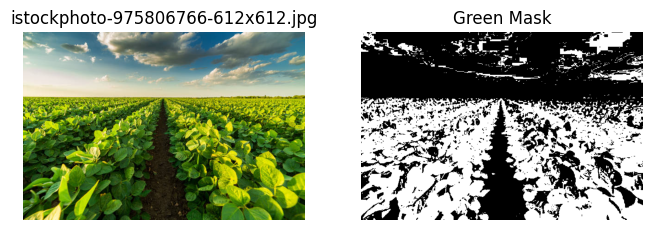

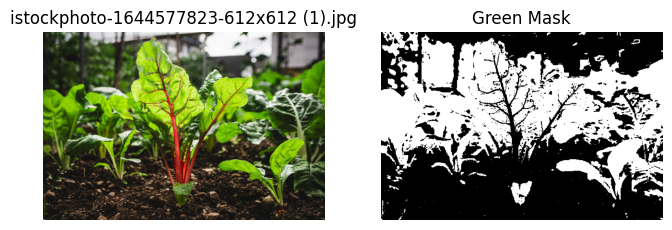

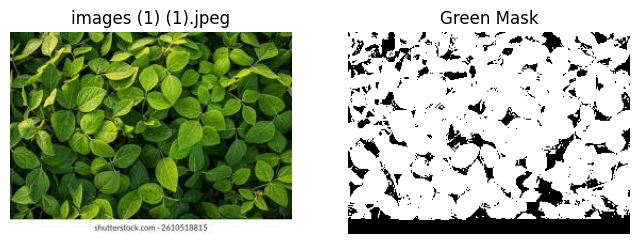

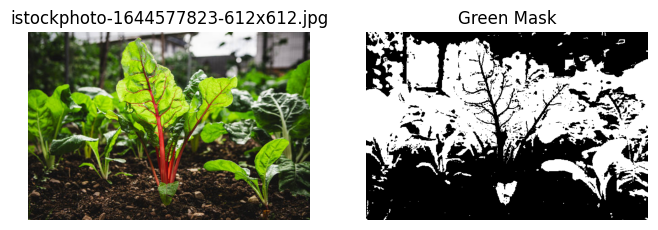

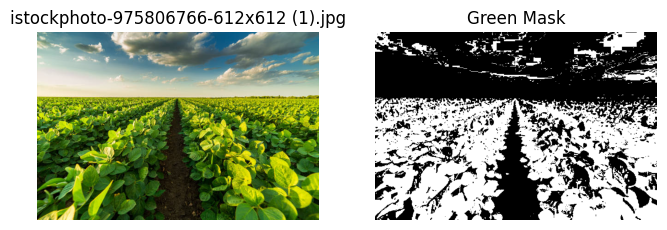

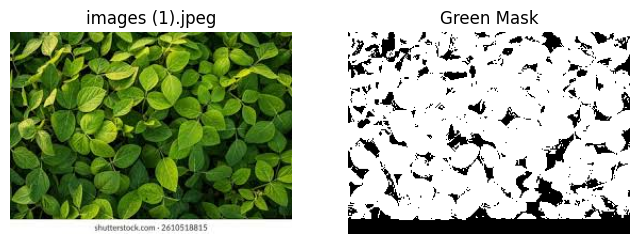

In [10]:
for file in image_files:
    image = cv2.imread(file)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lower_green = np.array([35, 40, 40])
    upper_green = np.array([90, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)

    plt.figure(figsize=(8,3))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title(file)
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(mask, cmap='gray')
    plt.title("Green Mask")
    plt.axis('off')

    plt.show()

In [11]:
!pip install gradio

In [12]:
import gradio as gr

def predict(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lower_green = np.array([35, 40, 40])
    upper_green = np.array([90, 255, 255])

    mask = cv2.inRange(hsv, lower_green, upper_green)
    ratio = np.sum(mask > 0) / mask.size

    prediction = model.predict([[ratio]])

    return f"Predicted Biomass: {prediction[0]:.2f}"

gr.Interface(fn=predict, inputs="image", outputs="text").launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://51730b7196ecdcb138.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
